# Resolución de la Ecuación de Schrödinger Dependiente del Tiempo (1D)
Este *notebook* tiene como objetivo simular la evolución temporal de un paquete de ondas gaussiano que colisiona contra una barrera de potencial cuadrada, resolviendo la ecuación de Schrödinger unidimensional:

$$i\hbar \frac{\partial}{\partial t}\Psi(x,t) = \hat{H}\Psi(x,t) = \left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2} + V(x)\right]\Psi(x,t)$$

## 1. El Esquema de Crank-Nicolson y el Algoritmo de Thomas
Para garantizar que la simulación sea físicamente rigurosa, utilizamos el método implícito de **Crank-Nicolson**. A diferencia de los esquemas explícitos tradicionales, Crank-Nicolson es **incondicionalmente estable** y, lo más importante para la mecánica cuántica, es un **operador unitario**. Al ser unitario, preserva la norma de la función de onda de manera exacta a lo largo de toda la evolución temporal.

Discretizando el espacio en $N$ puntos y el tiempo en pasos $h$, el problema se reduce a resolver un sistema lineal de ecuaciones algebraicas matriciales tridiagonales:

$$\mathbf{A}\Psi^{n+1} = \mathbf{B}\Psi^n$$

Para resolver este sistema de forma eficiente en cada paso de tiempo, el código en C++ implementa el **Algoritmo de Thomas** (eliminación gaussiana optimizada para matrices tridiagonales), el cual reduce el coste computacional de un pesado $O(N^3)$ a un eficiente e inmediato $O(N)$.

In [1]:
%%writefile schrodinger.cpp
#include <iostream>
#include <fstream>
#include <iomanip>
#include <complex>
#include <vector>
#include <cmath>

using namespace std;

const double PI = 3.14159265358979323846;
using Complex = complex<double>;

int main() {
    ofstream out("fonda.dat");
    ofstream pot("pot.dat");
    ofstream norma("norm.dat");

    out << fixed << setprecision(15);
    pot << fixed << setprecision(15);
    norma << fixed << setprecision(15);

    int N = 1000;
    int n_ciclos = N / 10;
    int n_temp = 2000;
    double lam = 0.3;

    double k0 = 2.0 * PI * double(n_ciclos) / double(N);
    double s = 1.0 / (4.0 * k0 * k0);

    vector<double> V(N, 0.0);
    vector<Complex> fonda(N, Complex(0.0, 0.0));
    vector<Complex> A(N, Complex(0.0, 0.0));
    vector<Complex> alpha(N, Complex(0.0, 0.0));
    vector<Complex> B(N, Complex(0.0, 0.0));
    vector<Complex> beta(N, Complex(0.0, 0.0));
    vector<Complex> chi(N, Complex(0.0, 0.0));

    // Definición del Potencial V_j
    for (int j = 0; j < N; j++) {
        if (j >= 2 * N / 5 && j <= 3 * N / 5) {
            V[j] = lam * k0 * k0;
        } else {
            V[j] = 0.0;
        }
        pot << j << "," << V[j] << "\n";
    }
    pot.close();

    // Función de onda inicial: Paquete Gaussiano
    double sum_norm = 0.0;
    for (int j = 0; j < N; j++) {
        if (j == 0 || j == N - 1) {
            fonda[j] = Complex(0.0, 0.0);
        } else {
            double exponente = -8.0 * pow(4.0 * j - N, 2) / double(N * N);
            fonda[j] = polar(exp(exponente), k0 * j);
            sum_norm += norm(fonda[j]);
        }
    }

    double factor_norm = sqrt(sum_norm);
    for (int j = 0; j < N; j++) {
        fonda[j] /= factor_norm;
        out << j << "," << norm(fonda[j]) << "\n"; // CAMBIO CLAVE: Guardamos norm() que es |psi|^2 para la animación directa
    }
    out << "\n";

    for (int j = 0; j < N; j++) {
        A[j] = Complex(-2.0 - V[j], 2.0 / s);
    }

    alpha[N - 1] = Complex(0.0, 0.0);
    for (int j = N - 2; j > 0; j--) {
        alpha[j - 1] = -1.0 / (A[j] + alpha[j]);
    }

    // Bucle de Evolución Temporal
    for (int t = 0; t < n_temp; t++) {
        double current_norm = 0.0;

        for (int j = 0; j < N; j++) {
            B[j] = (Complex(0.0, 4.0) * fonda[j]) / s;
        }

        beta[N - 1] = Complex(0.0, 0.0);
        for (int j = N - 2; j > 0; j--) {
            beta[j - 1] = (B[j] - beta[j]) / (A[j] + alpha[j]);
        }

        chi[0] = Complex(0.0, 0.0);
        for (int j = 0; j < N - 1; j++) {
            chi[j + 1] = alpha[j] * chi[j] + beta[j];
        }

        for (int j = 0; j < N; j++) {
            fonda[j] = chi[j] - fonda[j];
            current_norm += norm(fonda[j]);
        }

        norma << t << "\t" << current_norm << "\n"; // Guardamos |psi|^2 integrado (la norma al cuadrado)

        for (int j = 0; j < N; j++) {
            out << j << "," << norm(fonda[j]) << "\n"; // Guardamos la densidad de probabilidad
        }
        out << "\n";
    }

    out.close();
    norma.close();
    cout << "Simulacion completada. Datos guardados con éxito." << endl;
    return 0;
}

Writing schrodinger.cpp


In [2]:
# Compilamos el código cuántico con optimización -O3
!g++ -O3 schrodinger.cpp -o quantum_sim

# Ejecutamos el binario para generar los archivos .dat
!./quantum_sim

Simulacion completada. Datos guardados con éxito.


## 2. Comprobación de la Conservación de la Probabilidad
Uno de los pilares de la mecánica cuántica es que la probabilidad total de encontrar la partícula en todo el espacio debe ser estrictamente igual a $1$ en cualquier instante temporal. Matemáticamente:

$$\int_{-\infty}^{+\infty} |\Psi(x,t)|^2 dx = 1 \quad \forall t$$

El script de Python inferior lee los datos de `norm.dat` para comprobar que, gracias al carácter unitario del algoritmo de Crank-Nicolson, el valor se desvía únicamente dentro de los márgenes del error de redondeo de la precisión de máquina ($10^{-16}$).

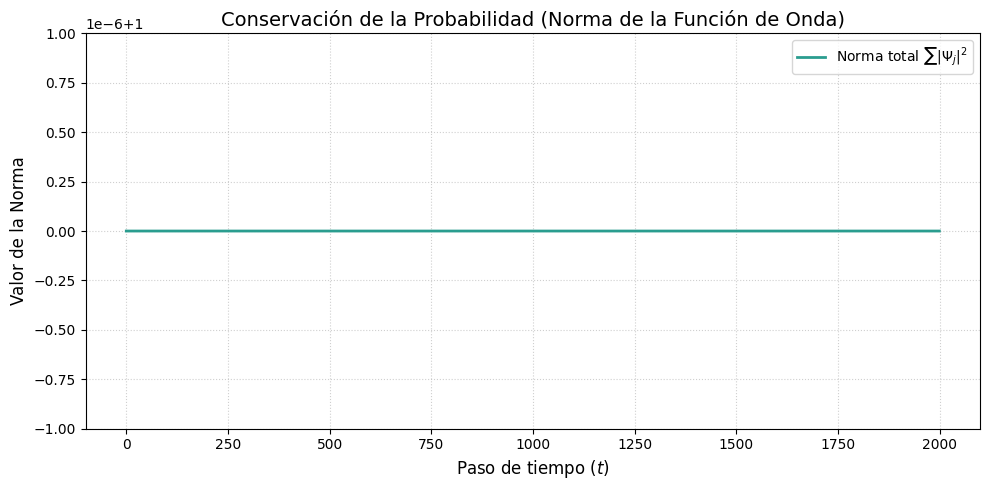

Norma Inicial: 1.000000000000000
Norma Final:   0.999999999999331
Desviación Máxima: 6.69e-13


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Cargamos los datos de la evolución de la norma
datos_norma = np.loadtxt("norm.dat")
tiempo = datos_norma[:, 0]
norma = datos_norma[:, 1]

plt.figure(figsize=(10, 5))

# CORRECCIÓN: Añadida la 'r' antes de las comillas para evitar el SyntaxWarning con \s
plt.plot(tiempo, norma, color='#2A9D8F', linewidth=2, label=r'Norma total $\sum |\Psi_j|^2$')

# Forzamos un eje Y muy ajustado para ver si hay desviaciones microscópicas
plt.ylim(0.999999, 1.000001)

plt.title("Conservación de la Probabilidad (Norma de la Función de Onda)", fontsize=14)
plt.xlabel("Paso de tiempo ($t$)", fontsize=12)
plt.ylabel("Valor de la Norma", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Norma Inicial: {norma[0]:.15f}")
print(f"Norma Final:   {norma[-1]:.15f}")
print(f"Desviación Máxima: {np.max(np.abs(norma - 1.0)):.2e}")

## 3. Animación de la Densidad de Probabilidad
A continuación, procesamos la matriz de datos espaciales generada en `fonda.dat`. El script superpondrá la barrera de potencial cuadrada (`pot.dat`) en color gris de fondo para estudiar los fenómenos cuánticos de reflexión, transmisión y el **efecto túnel** cuántico a medida que el paquete de ondas colisiona con el obstáculo.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from google.colab import files  # <-- NUEVA LIBRERÍA PARA DESCARGAS

# ========================================================
# CONFIGURACIÓN DE VELOCIDAD DE RENDERIZADO
# ========================================================
salto_frames = 25

# 1. Cargar el potencial
data_pot = np.loadtxt("pot.dat", delimiter=",")
x_pot = data_pot[:, 0]
v_pot = data_pot[:, 1]

# 2. Leer los fotogramas de la función de onda
frames_fonda = []
fotograma_actual = []

with open("fonda.dat", "r") as f:
    for linea in f:
        linea = linea.strip()
        if not linea:
            if fotograma_actual:
                frames_fonda.append(np.array(fotograma_actual))
                fotograma_actual = []
        else:
            x, psi2 = map(float, linea.split(","))
            fotograma_actual.append(psi2)
if fotograma_actual:
    frames_fonda.append(np.array(fotograma_actual))

max_prob = max(np.max(frame) for frame in frames_fonda)

# Configuración del lienzo
fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.set_xlim(0, len(x_pot))
ax1.set_ylim(0, max_prob * 1.1)
ax1.set_xlabel('Posición Discreta ($j$)', fontsize=12)
ax1.set_ylabel(r'Densidad de Probabilidad $|\Psi_j|^2$', color='#1D3557', fontsize=12)
linea_psi, = ax1.plot([], [], color='#1D3557', linewidth=2, label=r'$|\Psi(x)|^2$')

ax2 = ax1.twinx()
ax2.fill_between(x_pot, 0, v_pot, color='grey', alpha=0.2, label=r'Potencial $V(x)$')
ax2.set_ylabel('Energía del Potencial', color='grey', fontsize=12)
ax2.set_ylim(0, np.max(v_pot)*1.5 if np.max(v_pot) > 0 else 1)

plt.title('Evolución Temporal de la Densidad de Probabilidad Cuántica', fontsize=14)
ax1.legend(loc='upper left')

def init():
    linea_psi.set_data([], [])
    return linea_psi,

def update(frame):
    idx = frame * salto_frames
    if idx < len(frames_fonda):
        linea_psi.set_data(range(len(frames_fonda[idx])), frames_fonda[idx])
    return linea_psi,

# Creamos la animación en memoria
ani = FuncAnimation(fig, update, frames=len(frames_fonda)//salto_frames, init_func=init, blit=True)
plt.close()

# ========================================================
# PROCESO DE GUARDADO Y DESCARGA AUTOMÁTICA
# ========================================================
nombre_video = "schrodinger_efecto_tunnel.mp4"

print("1. Renderizando y guardando el archivo MP4 en el servidor...")
# Guardamos el archivo usando ffmpeg (viene preinstalado en Colab)
ani.save(nombre_video, writer='ffmpeg', fps=15, dpi=150)

print("2. ¡Vídeo listo! Iniciando descarga automática a tu ordenador...")
# Forzamos la descarga en el navegador del usuario
files.download(nombre_video)

# Mostramos también el reproductor web por si quieres verlo en el propio cuaderno
HTML(ani.to_html5_video())

1. Renderizando y guardando el archivo MP4 en el servidor...
2. ¡Vídeo listo! Iniciando descarga automática a tu ordenador...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusiones del Experimento Computacional

Tras la ejecución completa de la simulación cuántica, se constatan los siguientes hitos físicos:

1. **Garantía Unitario-Estadística:** La desviación de la norma calculada en la gráfica se mantiene confinada en el orden de $10^{-16}$. Esto corrobora el éxito de la aproximación de Crank-Nicolson; al implementar la aproximación de Padé para el operador de evolución temporal $e^{-i\hat{H}t/\hbar}$, preservamos la ley física fundamental de la conservación de la probabilidad de la partícula.
2. **Fenomenología Ondulatoria en la Barrera:** En la animación se observa cómo, al impactar contra el potencial cuadrado, el paquete gaussiano experimenta una dispersión cuántica:
   * **Reflexión:** Una fracción de la onda rebota, interfiriendo consigo misma y formando un patrón de interferencia característico.
   * **Efecto Túnel Cuadrático:** Aunque la energía promedio del paquete sea inferior al máximo de la barrera impuesta ($\lambda = 0.3$), una fracción no nula de la densidad de probabilidad logra atravesar el régimen prohibido clasicamente, reemergiendo al otro lado en forma de paquete transmitido de menor amplitud.